# Data Vortex · Round 1 · Phase 1 — Walkthrough notebook
**Team SE7EN** — Tanmay Singh · Panshul Arora

This notebook is the step-by-step, evidence-first companion to the pipeline. It **imports the same functions** used by `src/clean.py` (no copy-pasted logic), shows the evidence behind every cleaning decision, then runs the full pipeline, the validation suite and the key statistical tests.

| Step | What it shows |
|---|---|
| 0 | Raw files load as text, and their SHA-256 matches the recovered archive |
| 1 | Duplicates are exact copies |
| 2 | Three timestamp encodings, one of which lost its time of day |
| 3 | Two spellings of "missing" |
| 4 | Negative likes are a sign flip |
| 5 | Five injected text suffixes |
| 6 | Full pipeline run, byte-identical to the files on disk |
| 7 | Validation suite |
| 8 | EDA highlights and the tests behind them |

> Reproduce everything with `python run_all.py`. Run this notebook from the `notebooks/` folder.

In [1]:
import sys, re, hashlib, json
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import clean  # the production cleaning module

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)
print("repo root:", ROOT)

repo root: E:\datavortex\TEAM SE7EN DATAVORTEX


## 0 · Load the raw files as text
Every cell is read as a string with `keep_default_na=False`, so pandas cannot silently turn `'NULL'` or `''` into NaN. Each corruption has to be found by an explicit rule.

In [2]:
raw_posts = clean.load_raw(clean.RAW_POSTS)
raw_users = clean.load_raw(clean.RAW_USERS)
for path in (clean.RAW_POSTS, clean.RAW_USERS):
    digest = clean.sha256(path)
    print(f"{path.name:36s} sha256={digest[:16]}…  matches archive: {digest == clean.EXPECTED_SHA256[path.name]}")
print("posts", raw_posts.shape, "| users", raw_users.shape)
raw_posts.head(8)

Social_Engine_Posts_Corrupted.csv    sha256=49a460d6b6d8b7f5…  matches archive: True
Social_Engine_Users.csv              sha256=d30efe470a4dd561…  matches archive: True
posts (12360, 8) | users (1500, 5)


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,"Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fashion&amp;",25-09-2024,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,"My one month review of Pepsi Crystal Pepsi: Highly recommend. #Premium, #Fashion Would love to get your fe...",1722528840,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,,Just unboxed my new Highlander from Toyota. Exceeded my expectations. Confused about #Beauty Really intere...,2025-04-13T20:12:18,NULL,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,"Comparing Pepsi Crystal Pepsi to the competition. Best purchase ever. #Promo, #NewRelease Curious about yo...",10-09-2024,167,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,"My one week review of Coca-Cola Diet Coke: Best purchase ever. #BestValue, #Reviews Would love to get your...",31-05-2024,4749,152,630
5,f85c8vm8ac8l,user_aedwfomw,,"Adidas ValentinesDeals is disappointing! Can't wait to see what's coming next. #NewRelease, #Affordable, #...",24-01-2025,3694,192,135
6,19ys654yi1if,user_27aje6ur,Facebook,"Fed up with my new iPhone 15 from Apple! Best purchase ever. #Fashion, #Eco, #CustomerService",1719394663,,1578,514
7,5jywsz1bu0kp,user_hvqqyzoi,Twitter,"Just unboxed my new React from Nike. Not bad. Bummed out #TrendAlert, #Health, #Travel Really interested i...",2025-03-27T13:44:32,434,1683,785


## 1 · Duplicates are exact copies
A duplicate `post_id` may only be dropped if every column matches. Otherwise the copies would need merging.

In [3]:
dups = raw_posts[raw_posts.duplicated("post_id", keep=False)]
groups = dups.groupby("post_id")
conflicting = sum(len(g.drop_duplicates()) > 1 for _, g in groups)
print("duplicated post_ids:", groups.ngroups, "| group sizes:", groups.size().value_counts().to_dict())
print("rows to remove:", int(raw_posts.duplicated("post_id").sum()), "| groups whose copies disagree:", conflicting)
dups.sort_values("post_id").head(4)

duplicated post_ids: 352 | group sizes: {2: 344, 3: 8}
rows to remove: 360 | groups whose copies disagree: 0


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
10546,01jzjra6mmwc,user_bqp8mrav,YouTube,"Comparing Toyota Corolla to the competition. Not worth the money. #NewRelease, #Sustainable Would love to ...",2024-10-13T15:19:29,2829,776,654
3003,01jzjra6mmwc,user_bqp8mrav,YouTube,"Comparing Toyota Corolla to the competition. Not worth the money. #NewRelease, #Sustainable Would love to ...",2024-10-13T15:19:29,2829,776,654
6645,03gqkhd2ebdg,user_ysbkmmxf,Facebook,My two days review of Adidas Stan Smith: Worth every penny. #NewRelease Really interested in hearing your ...,2024-10-20T20:14:36,,966,833
11348,03gqkhd2ebdg,user_ysbkmmxf,Facebook,My two days review of Adidas Stan Smith: Worth every penny. #NewRelease Really interested in hearing your ...,2024-10-20T20:14:36,,966,833


## 2 · Three timestamp encodings, one without a time of day

In [4]:
ts = raw_posts.timestamp
fmt = np.select([ts.str.fullmatch(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}"), ts.str.fullmatch(r"\d{10}"), ts.str.fullmatch(r"\d{2}-\d{2}-\d{4}")],
                ["iso8601", "unix_epoch", "dd-mm-yyyy"], "UNKNOWN")
print(pd.Series(fmt).value_counts().to_dict())
dmy = ts[fmt == "dd-mm-yyyy"]
print("dd-mm-yyyy: max 1st field =", dmy.str[:2].astype(int).max(), "| max 2nd field =", dmy.str[3:5].astype(int).max(),
      "→ day-first; no time component")
pd.DataFrame({"raw": ts.groupby(fmt).head(2).values}).assign(format=lambda d: d.raw.map(lambda v: fmt[ts[ts == v].index[0]]))

{'iso8601': 4950, 'unix_epoch': 3788, 'dd-mm-yyyy': 3622}
dd-mm-yyyy: max 1st field = 31 | max 2nd field = 12 → day-first; no time component


,raw,format
0,25-09-2024,dd-mm-yyyy
1,1722528840,unix_epoch
2,2025-04-13T20:12:18,iso8601
3,10-09-2024,dd-mm-yyyy
4,1719394663,unix_epoch
5,2025-03-27T13:44:32,iso8601


**Decision:** Unix epochs → UTC datetime. `dd-mm-yyyy` → keep the **date**, set `post_datetime_utc = NULL`, `timestamp_precision = 'day'`.
Padding these with `00:00:00` would invent a time for ~29% of posts and create a fake midnight spike (Step 8).

## 3 · Two spellings of missing

In [5]:
pd.DataFrame({c: {"''": int((raw_posts[c] == "").sum()), "'NULL'": int((raw_posts[c] == "NULL").sum())}
              for c in raw_posts.columns}).T.query("`''` > 0 or `'NULL'` > 0")

,'','NULL'
platform,1219,627
text_content,1196,550
likes,1229,629


## 4 · Negative likes are a sign flip, not dislikes

In [6]:
likes = raw_posts.likes[~raw_posts.likes.isin(["", "NULL"])]
is_float = likes.str.fullmatch(r"-?\d+\.\d+")
num = likes.astype(float)
print("negative values:", int((num < 0).sum()), "| negatives float-formatted:", int(((num < 0) & is_float).sum()),
      "| non-negatives float-formatted:", int(((num >= 0) & is_float).sum()))
ks = stats.ks_2samp(num[num >= 0], -num[num < 0])
print(f"KS test |negative| vs positive on the raw file: p = {ks.pvalue:.3f} (same distribution; the report quotes the de-duplicated value)")
likes[num < 0].head(5).tolist()

negative values: 525 | negatives float-formatted: 525 | non-negatives float-formatted: 0
KS test |negative| vs positive on the raw file: p = 0.601 (same distribution; the report quotes the de-duplicated value)


['-4812.0', '-1795.0', '-3707.0', '-4543.0', '-3194.0']

## 5 · Five injected text suffixes
Each artifact is checked to occur **only** at the end of the string. If one ever appeared mid-text, the pipeline would stop instead of stripping it.

In [7]:
t = raw_posts.text_content
rows = []
for name, pat in clean.TEXT_SUFFIX_ARTIFACTS.items():
    rows.append({"artifact": name, "pattern": pat, "rows_anywhere": int(t.str.contains(pat, regex=True).sum()),
                 "rows_as_suffix": int(t.str.contains(rf"(?:{pat})\Z", regex=True).sum())})
pd.DataFrame(rows)

,artifact,pattern,rows_anywhere,rows_as_suffix
0,html_entity_amp,&amp;,341,341
1,html_tag_br,<br>,325,325
2,html_tag_div,<div>,338,338
3,mojibake_e_acute,Ã©,316,316
4,trailing_newlines,\n+,337,337


In [8]:
examples = t[t.str.contains(r"(?:&amp;|<br>|<div>|Ã©|\n+)$", regex=True)].groupby(
    t.str.extract(r"(&amp;|<br>|<div>|Ã©|\n+)$")[0].str.replace("\n+", "\\n\\n", regex=True)).head(1)
pd.DataFrame({"raw (repr)": examples.map(repr).values})

,raw (repr)
0,"'Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fashion&amp;'"
1,"'Just unboxed my new Halo Band from Amazon. Exceeded my expectations. Confused about #Food, #TravelÃ©'"
2,"""Could someone explain with my new Air Max from Nike! It's okay. #Quality, #Limited, #Trending\n\n"""
3,"""Just tried the Superstar from Adidas. Wouldn't recommend. #MustHave, #Deal Would love to get your feedbac..."
4,"'Just saw an ad for Samsung Neo QLED TV during the ValentinesDeals. Absolutely loving it. #Affordable, #Be..."


## 6 · Run the full pipeline
The in-memory run must reproduce the committed files byte-for-byte.

In [9]:
import io
posts, users, audit, changes = clean.run(write=False)
for name, frame in [("posts_cleaned.csv", posts), ("users_cleaned.csv", users)]:
    buf = io.StringIO(); frame.to_csv(buf, index=False, lineterminator="\n")
    same = hashlib.sha256(buf.getvalue().encode()).hexdigest() == clean.sha256(ROOT / "data/cleaned" / name)
    print(f"{name}: identical to file on disk = {same}")
print(posts.shape, users.shape)
posts.head(5)

posts_cleaned.csv: identical to file on disk = True
users_cleaned.csv: identical to file on disk = True
(12000, 14) (1500, 8)


,post_id,user_id,platform,text_content,post_date,post_datetime_utc,timestamp_precision,timestamp_source_format,likes,shares,comments,dq_duplicate_copies_removed,dq_likes_sign_corrected,dq_text_artifact_removed
0,to64mgey2v3y,user_vfxs1pry,Reddit,"Bummed out with my new Air Max from Nike! Absolutely loving it. #Travel, #CustomerService, #Fashion",2024-09-25,None,day,dd-mm-yyyy,4488,1456,673,0,0,html_entity_amp
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,"My one month review of Pepsi Crystal Pepsi: Highly recommend. #Premium, #Fashion Would love to get your fe...",2024-08-01,2024-08-01 16:14:00,second,unix_epoch,789,1484,39,1,0,none
2,dvvhg8eel45x,user_nfo3ih5u,None,Just unboxed my new Highlander from Toyota. Exceeded my expectations. Confused about #Beauty Really intere...,2025-04-13,2025-04-13 20:12:18,second,iso8601,<NA>,1410,839,0,0,none
3,hgb9cxke4t7b,user_27aje6ur,Facebook,"Comparing Pepsi Crystal Pepsi to the competition. Best purchase ever. #Promo, #NewRelease Curious about yo...",2024-09-10,None,day,dd-mm-yyyy,167,584,833,0,0,none
4,zwerpw3wk320,user_9px5q0by,Reddit,"My one week review of Coca-Cola Diet Coke: Best purchase ever. #BestValue, #Reviews Would love to get your...",2024-05-31,None,day,dd-mm-yyyy,4749,152,630,0,0,none


In [10]:
print("NULLs remaining (unrecoverable):", audit["output"]["posts_null_counts"])
changes.groupby(["column", "rule"]).size().rename("values changed").to_frame()

NULLs remaining (unrecoverable): {'platform': 1784, 'text_content': 1779, 'post_datetime_utc': 3526, 'likes': 1814}


values changed
column       rule                                           
*row*        drop_exact_duplicate                        360
likes        missing_token_to_null                      1814
             sign_flip_abs                               509
platform     missing_token_to_null                      1784
text_content collapse_whitespace                         680
             missing_token_to_null                      1779
             strip_suffix_artifact                      1609
timestamp    dd-mm-yyyy_to_date_time_unknown            3526
             unix_epoch_to_utc_datetime                 3669

## 7 · Validation suite

In [11]:
import validate
exit_code = validate.main()
print("exit code:", exit_code)

[PASS] structure       posts columns match data dictionary
[PASS] structure       users columns match data dictionary
[PASS] structure       row count = raw rows - duplicate rows removed
[PASS] structure       every raw post_id survives exactly once
[PASS] keys            post_id unique, 12 lowercase alphanumerics
[PASS] keys            user_id unique in users
[PASS] keys            every post.user_id exists in users (FK)
[PASS] missing tokens  no 'NULL'-style tokens left in posts.post_id
[PASS] missing tokens  no 'NULL'-style tokens left in posts.user_id
[PASS] missing tokens  no 'NULL'-style tokens left in posts.platform
[PASS] missing tokens  no 'NULL'-style tokens left in posts.text_content
[PASS] missing tokens  no 'NULL'-style tokens left in posts.post_date
[PASS] missing tokens  no 'NULL'-style tokens left in posts.post_datetime_utc
[PASS] missing tokens  no 'NULL'-style tokens left in posts.timestamp_precision
[PASS] missing tokens  no 'NULL'-style tokens left in posts.timestam

## 8 · EDA highlights (the full analysis lives in `src/eda.py` and the PDF report)

Real posts at hour 0: 376 (mean per hour 353); chi-square uniform p = 0.475
If date-only posts were padded to midnight: 3902 at hour 0 → a fake 11.1x spike


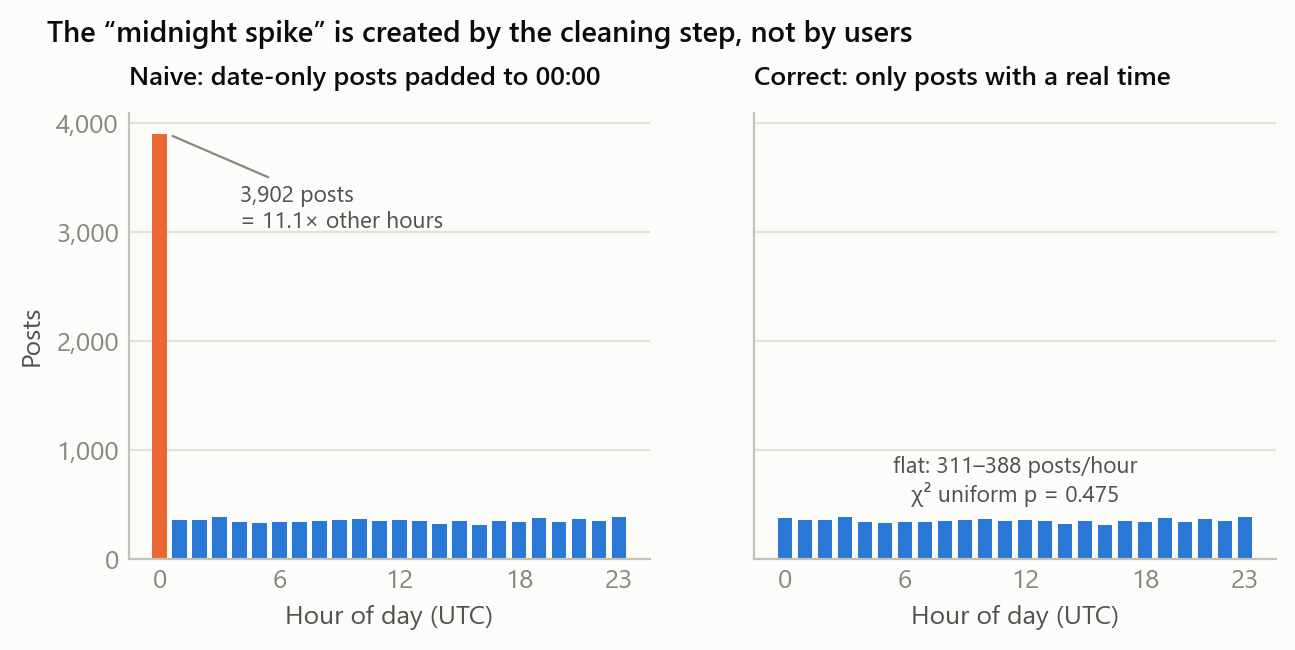

In [12]:
cleaned = pd.read_csv(ROOT / "data/cleaned/posts_cleaned.csv", parse_dates=["post_date", "post_datetime_utc"])
timed = cleaned[cleaned.timestamp_precision == "second"]
true_hours = timed.post_datetime_utc.dt.hour.value_counts().sort_index()
naive_hour0 = true_hours[0] + (cleaned.timestamp_precision == "day").sum()
print(f"Real posts at hour 0: {true_hours[0]} (mean per hour {true_hours.mean():.0f}); chi-square uniform p = {stats.chisquare(true_hours).pvalue:.3f}")
print(f"If date-only posts were padded to midnight: {naive_hour0} at hour 0 → a fake {naive_hour0 / true_hours.drop(0).mean():.1f}x spike")
display(Image(ROOT / "reports/figures/fig03_midnight_artifact.png", width=820))

Spearman followers vs mean engagement/post: 0.011
Spearman post count vs total engagement:   0.841


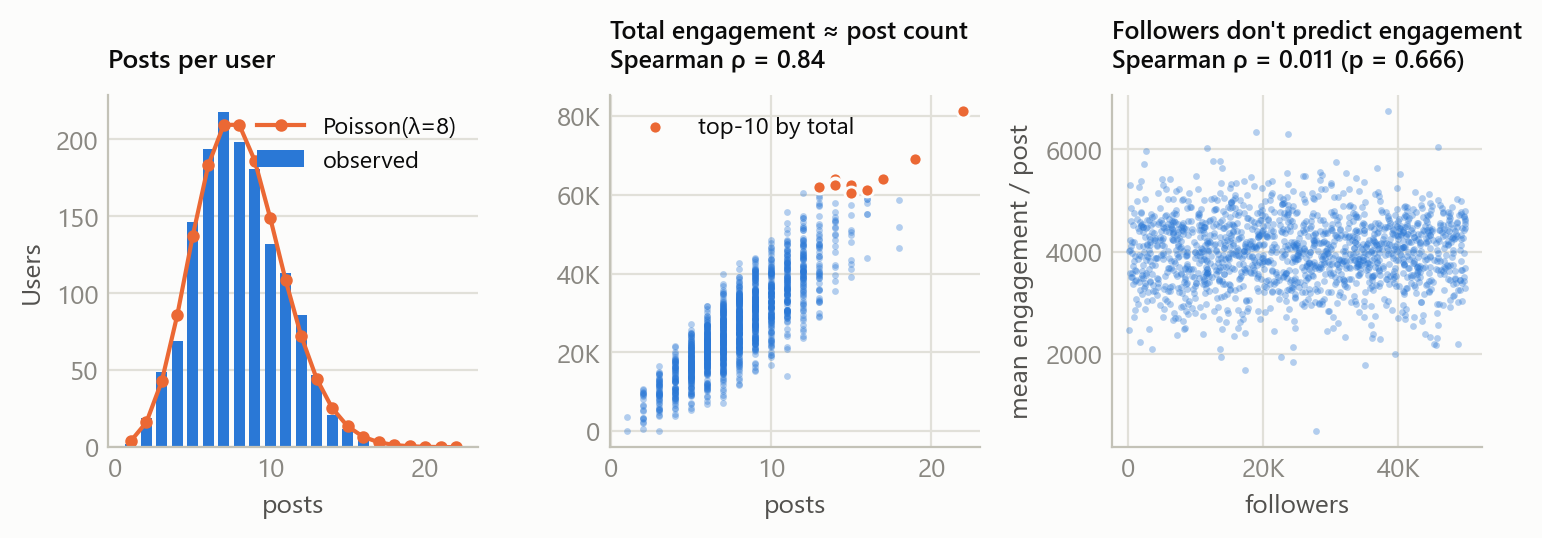

In [13]:
u = cleaned.assign(engagement=cleaned.likes + cleaned.shares + cleaned.comments).groupby("user_id").agg(
    posts=("post_id", "size"), total=("engagement", "sum"), mean=("engagement", "mean")).join(
    pd.read_csv(ROOT / "data/cleaned/users_cleaned.csv").set_index("user_id"))
print("Spearman followers vs mean engagement/post:", round(stats.spearmanr(u.follower_count, u["mean"], nan_policy="omit").statistic, 3))
print("Spearman post count vs total engagement:  ", round(stats.spearmanr(u.posts, u.total).statistic, 3))
display(Image(ROOT / "reports/figures/fig08_user_activity.png", width=820))

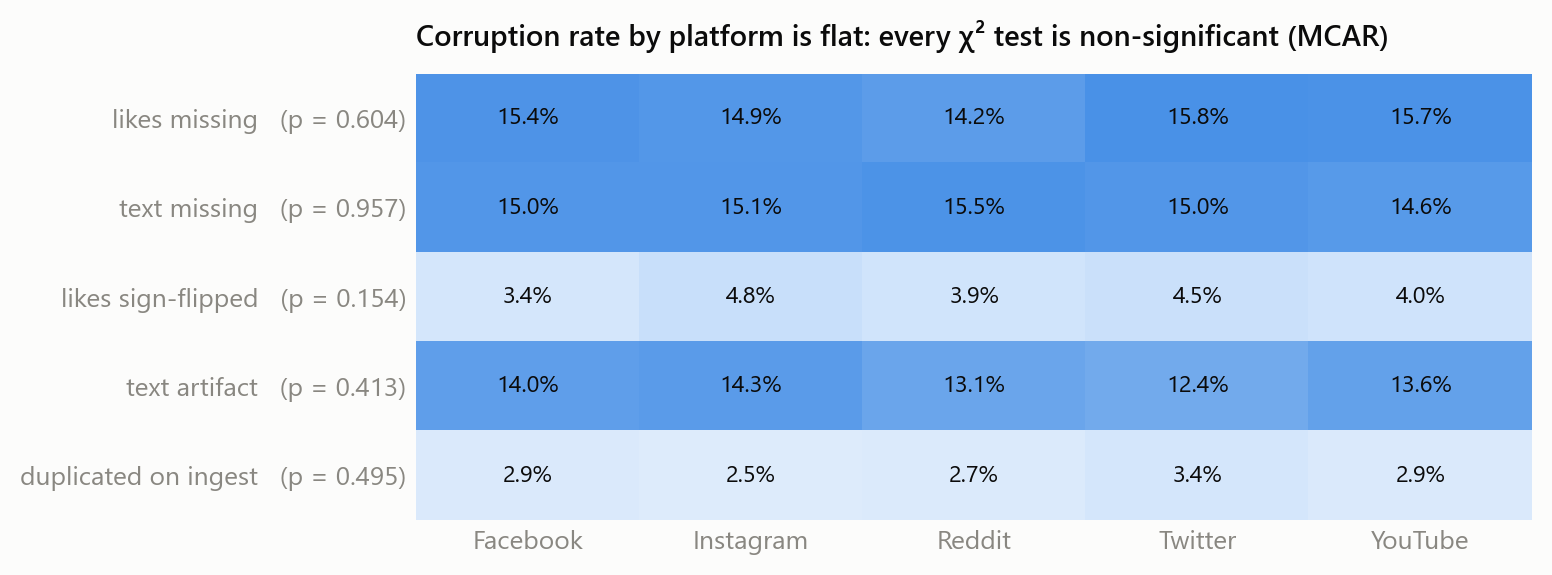

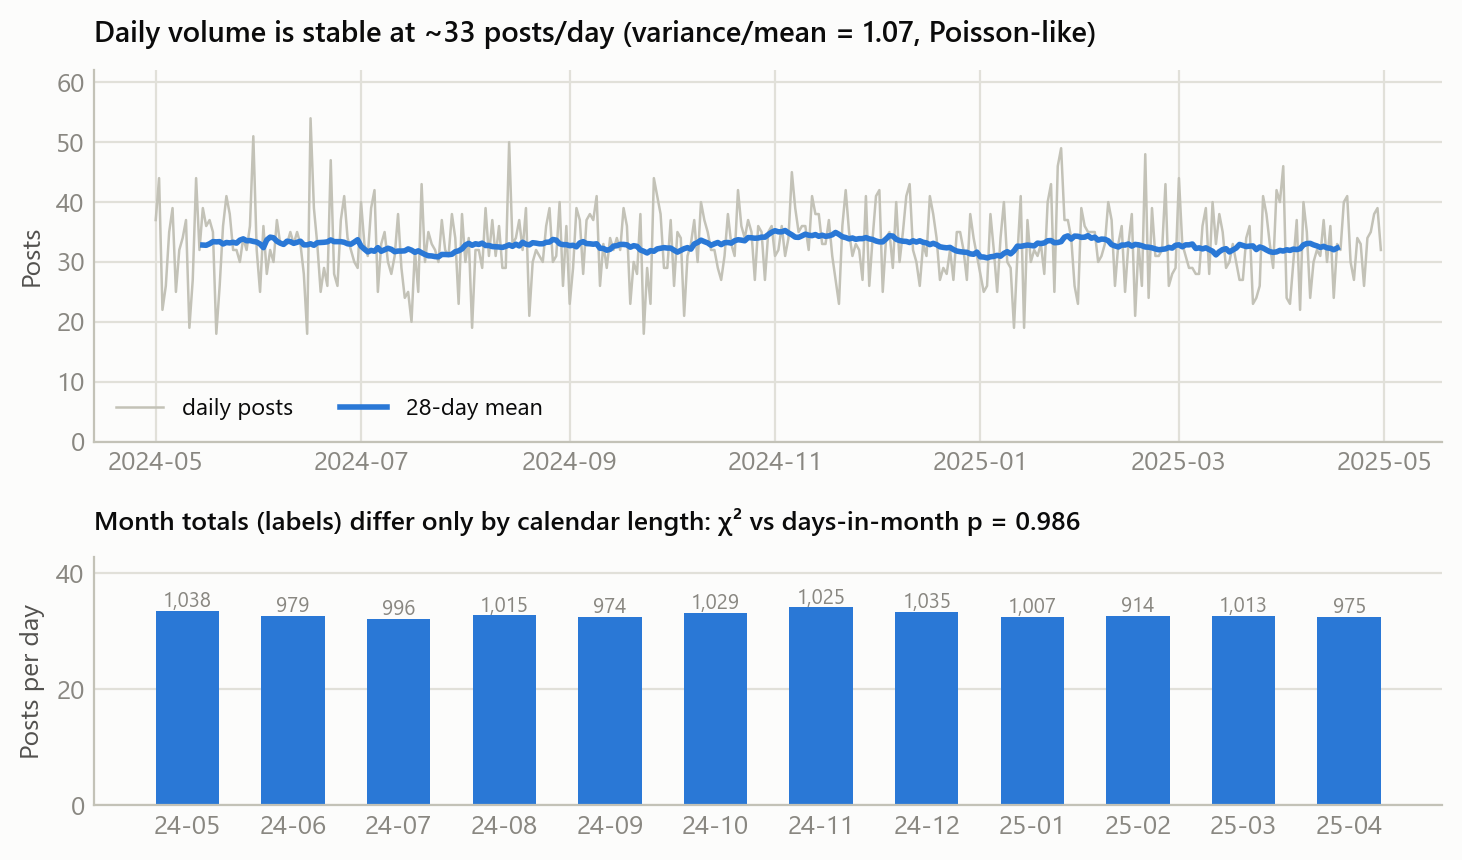

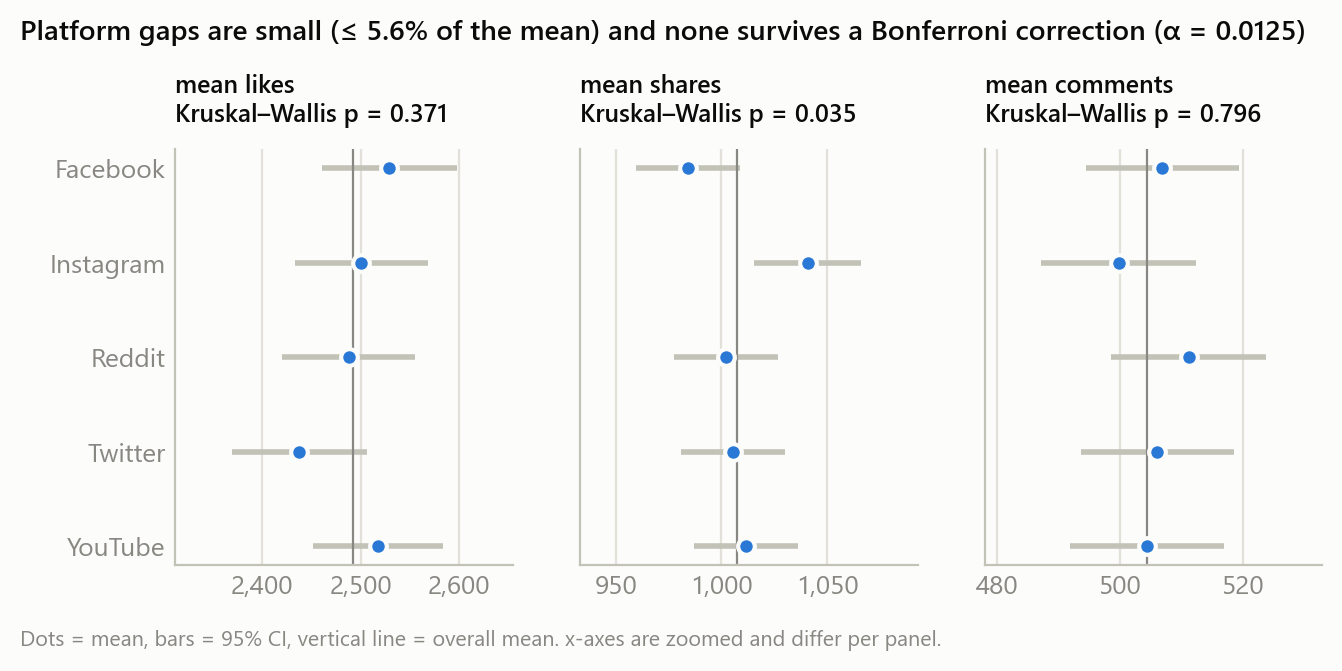

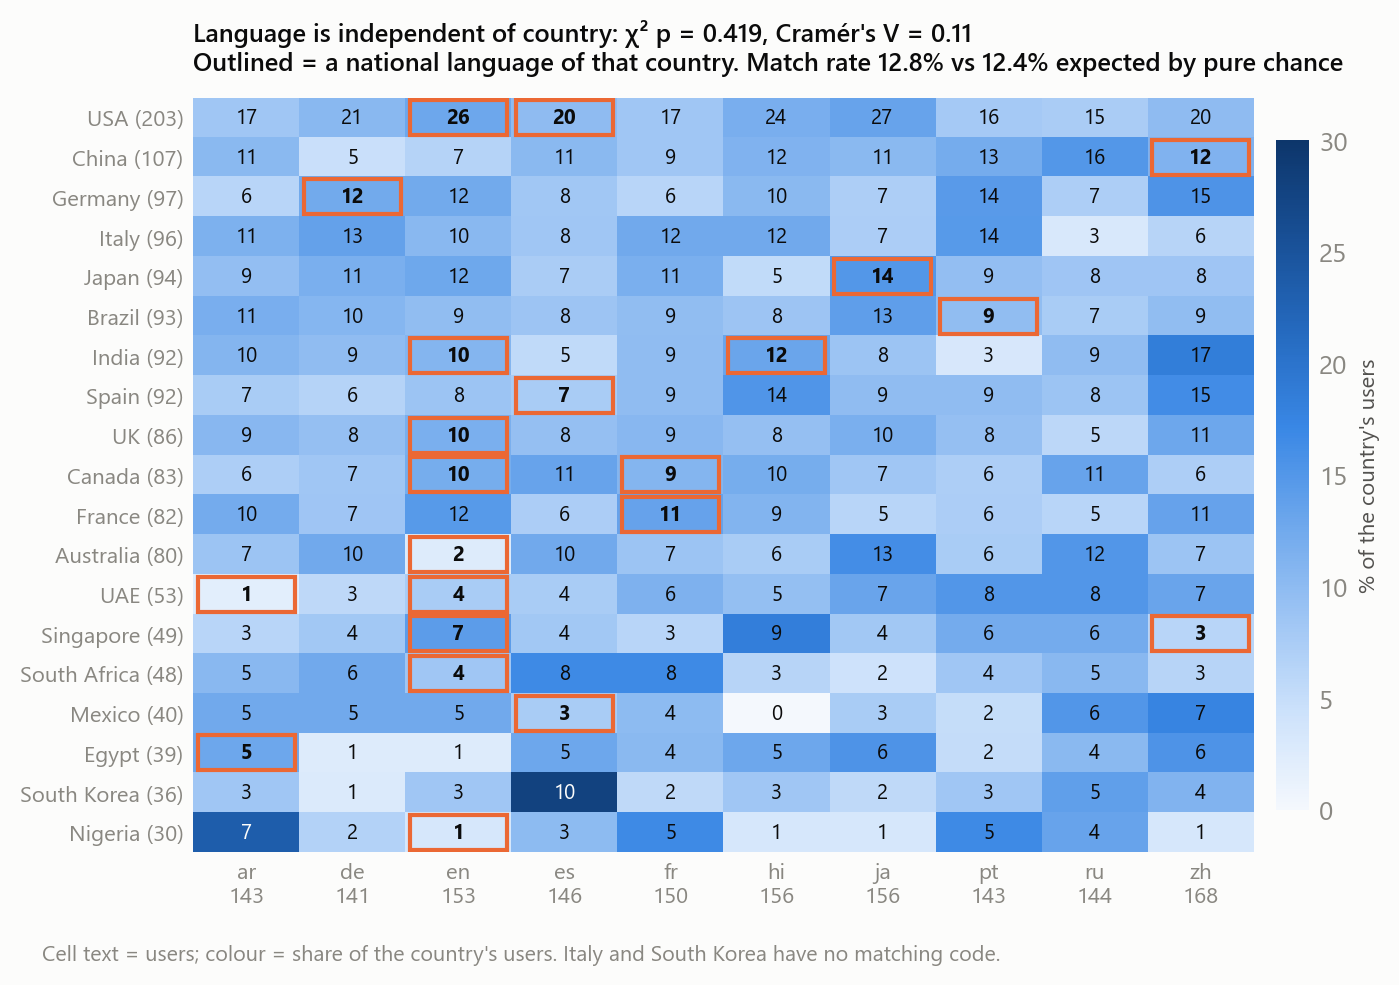

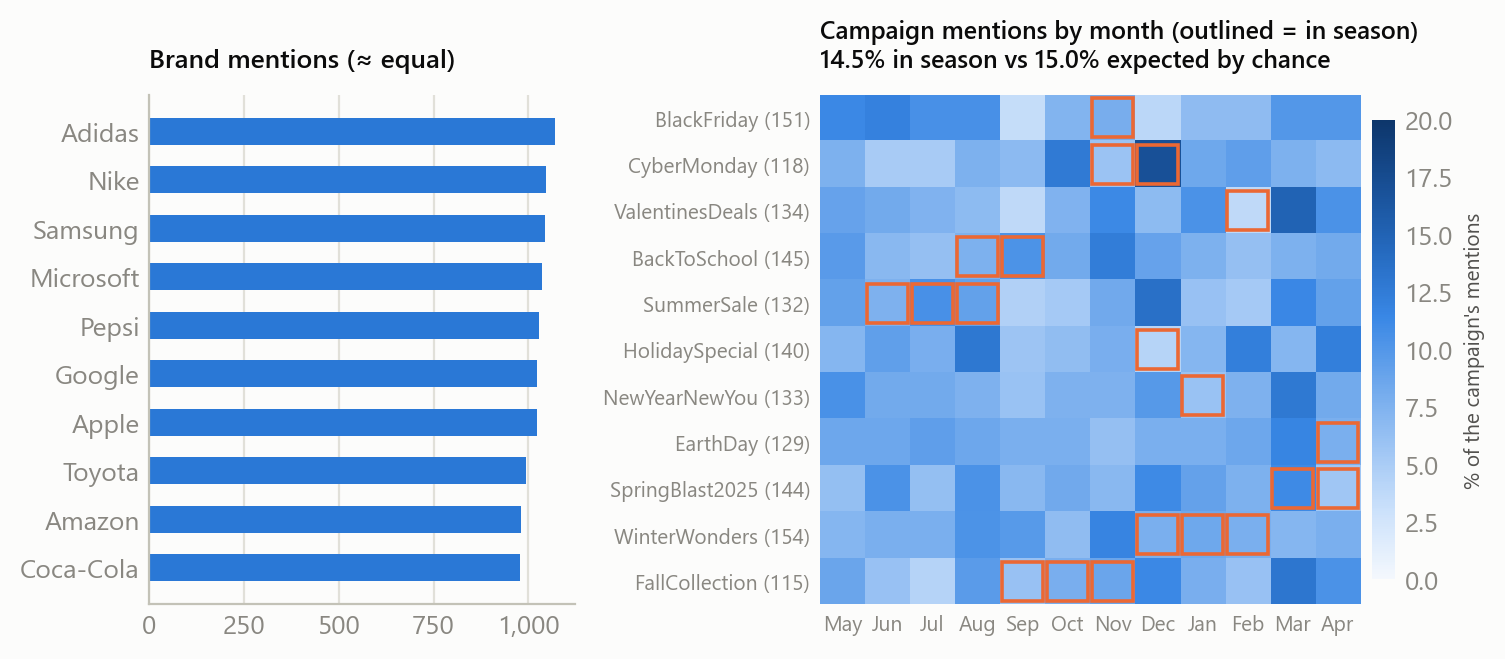

In [14]:
for f in ["fig02_missingness_mcar", "fig05_volume_over_time", "fig06_platform_engagement", "fig09_language_vs_country", "fig10_text_brands_campaigns"]:
    display(Image(ROOT / f"reports/figures/{f}.png", width=760))

## Conclusions
1. **Nine corruption types** were detected with explicit, asserted evidence and fixed without inventing values.
2. **Unrecoverable values stay NULL.** They are missing completely at random, so available-case analysis is unbiased.
3. **The midnight spike is a parsing artifact.** Real posting is flat across the day.
4. The data shows **stationary volume**, **independent uniform engagement**, **no platform effect**, **no follower effect**, **language independent of location** and **templated text** (see the report for all tests).

Outputs: `data/cleaned/`, `reports/EDA_Report_Team_SE7EN.pdf`, `reports/cleaning_audit.json`, `reports/change_log.csv`, `reports/validation_report.md`.